In [68]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "solar"
aggregation = "asset"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Historical random curves and day-ahead forecasts

In [69]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_solar_2018.pkl",
    T=288,
)
print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased=True,
    path_to_training_data=DATA / "linear_preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "linear_preprocessed_solar_2018.pkl",
    T=288,
)
print(E_tr_lin_.shape, E_ts_lin_.shape)

E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased=False,
    path_to_training_data=DATA / "preprocessed_solar_2017.pkl",
    path_to_testing_data=DATA / "preprocessed_solar_2018.pkl",
    T=288,
)
print(E_tr_biased_.shape, E_ts_biased_.shape)

(76593, 288) (364, 288, 211)
(76593, 288) (364, 288, 211)
(76593, 2) (211, 2)
(76593, 288) (364, 288)
(76593, 1) (211,)
(76593,) (364,)
(288,) (288,)
(76593, 288) (364, 288, 211)
(76593, 288) (364, 288, 211)


In [70]:
# exp_description="unbiased-025"
# #_init = {120: 1, 132: 4, 144: 1, 168: 4}
# _init = {120: 1, 144: 1, 168: 4}

exp_description="unbiased-025-1"
_init = {120: 1, 144: 2, 168: 2}

exp_description="unbiased-025-2"
_init = {120: 3, 144: 2, 168: 2}

exp_description="unbiased-025-3"
_init = {120: 3, 144: 3, 168: 1}

exp_description="unbiased-025-6"
_init = {120: 1, 144: 1, 168: 1}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation = VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)

time                    120         144         168
p_fusion           0.900000    0.900000    0.900000
forget_rate_f      0.125000    0.125000    0.125000
forget_rate_e      1.000000    1.000000    1.000000
lookahead_rate     4.000000    4.000000    4.000000
tau                0.010000    0.010000    0.010000
kappa            150.000000  150.000000  150.000000
rho_e              0.024700    0.000441    0.168399
rho_d              0.008526    0.553295    2.435167
kappa_0         2315.000000  300.000000  264.000000
nu                 7.000000    8.000000   10.000000
sigma              0.149565    0.146833    0.458253
length_scale_f   100.000000  100.000000  100.000000
length_scale_e     2.469985    0.044096   16.839885
length_scale_d     0.852623   55.329464  243.516723


In [71]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION
)
print(df_fmt)

df_fmt, latex = loader.envelope_scores(
    envelope_, 
    alphas = [0.1, 0.2]
)
print(df_fmt)

   Forecast Update Time $\tau$               Estimator    RMSE     MAE     MBE
0                          120                     NaN  0.1438  0.0873  0.0014
1                          120   $\hat{\mu}_{deep}(s)$  0.1465  0.0888  0.0033
2                          120  $\hat{\mu}_{focal}(s)$  0.1418  0.0918  0.0039
3                          144                     NaN  0.1157  0.0654 -0.0086
4                          144   $\hat{\mu}_{deep}(s)$  0.1169  0.0664 -0.0074
5                          144  $\hat{\mu}_{focal}(s)$  0.1178  0.0707  0.0020
6                          168                     NaN  0.0998  0.0524 -0.0036
7                          168   $\hat{\mu}_{deep}(s)$  0.1000  0.0527 -0.0018
8                          168  $\hat{\mu}_{focal}(s)$  0.1010  0.0559  0.0028
                 FIS                                                 FCS  \
                 MBD            fknn          MBDnom      ECDF       MBD   
               score  frac     score  frac     score     s

# Functional kNNs dynamic update

Basalt Solar 2018-01-25 11:00:00
1.0037245305139764 232.47904403138565
Basalt Solar 2018-01-25 11:00:00
[0 2] [1253   54]
solar-13-24-132-asset


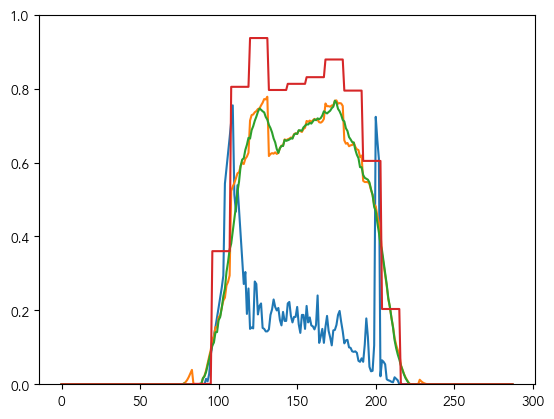

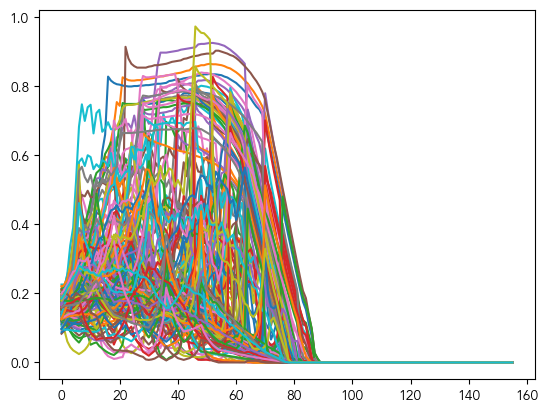

0.13955121692788014


In [98]:
day = 24
asset = 13
interval = 132

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", "spatial": "haversine", 'fusion': 'dynamic'},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)
print(_fdu.name, _fdu.date)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(F_tr_, E_tr_biased_, t_tr_, day, day_window=7)

_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_=X_tr_,
    t_=t_tr_,
    interval_mask=interval_mask,
    n_samples_per_hour=12,
)

M_ = _fdu.predict(
    F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], X_ts_[asset, :], t_ts_[day],          
    forget_rate_f = get_hyper(hyper_, 'forget_rate_f', interval),
    forget_rate_e = get_hyper(hyper_, 'forget_rate_e', interval),
    lookahead_rate = get_hyper(hyper_, 'lookahead_rate', interval),
    length_scale_f = get_hyper(hyper_, 'length_scale_f', interval),
    length_scale_e = get_hyper(hyper_, 'length_scale_e', interval),
    length_scale_d = get_hyper(hyper_, 'length_scale_d', interval),
    sigma = get_hyper(hyper_, 'sigma', interval),
    nu = get_hyper(hyper_, 'nu', interval),
    kappa_0 = get_hyper(hyper_, 'kappa_0', interval),
    kappa = get_hyper(hyper_, 'kappa', interval),
    p_fusion = get_hyper(hyper_, 'p_fusion', interval)
)
print(np.exp(_fdu.xi), _fdu.r)
x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
print(_fdu.name, _fdu.date)
print(x_, y_)

# Plotting variables
e_ = E_ts_[day, :, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_biased_ = E_ts_biased_[day, :, asset]
f_ = F_ts_[day, :interval, asset]
f_hat_ = F_ts_[day, interval:, asset]
x_ts_ = X_ts_[asset, :]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_biased_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()
print(M_.mean())
# Bluebonnet Solar
# BlueBell Solar

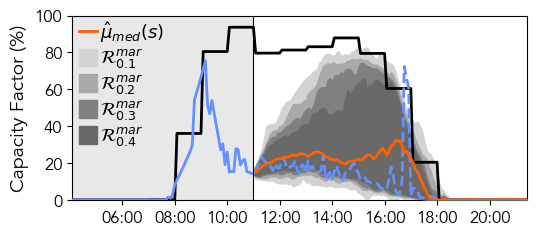

In [99]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    #n_basis=20,
    n_basis=int(1.333*(T - interval)/12)
)

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    M_int_, 
    alpha_,
)

f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_region(
    M_int_, 
    _fdu.w_prime_,
    alpha_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_median_ext_, f_, f_hat_, e_biased_, dx_,
    dt_=dt_ + 5, 
    interval=interval,
    n=120,
    color_med=palette_.loc[3, "ibm"],
    CR=r"$\mathcal{{R}}^{{mar}}_{{{}}}$",
    label = r"$\hat{\mu}_{med} (s)$",
    range_ = [48, 256],
    legend_1=False,
    legend_2=True,
)

# _ax.legend(
#     frameon = False,
#     #loc=(0.2125, 0.),
#     loc='upper left',
#     fontsize = 12,
#     columnspacing=0.5,
#     handletextpad=0.25,
#     ncol = 1
# )

_ax.legend(
    frameon = False,
    loc = (0.0, .24),
    #loc='upper left',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

In [100]:
print(interval)
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025",
    path_to_validation=VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.5, 2.5), 
    constrained_layout = True)

INTERVAL = 27
LEAD = 9
bins = 10
print((interval + INTERVAL)/12, (interval + INTERVAL + LEAD)/12)
plotter.plot_pit(
    _fig, _ax, pit_[:, INTERVAL:(INTERVAL + LEAD)].flatten(), 
    v = 0.4,
    bins = bins,
    xlabel = 'PIT (from 13:15h to 2:00h)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{INTERVAL}-{LEAD}-{interval}.pdf"
)

plt.show()

132


FileNotFoundError: [Errno 2] No such file or directory: '/Users/Guille/Desktop/dynamic_update/validation/solar/solar_fusion_asset-PIT_132-unbiased-025.csv'

# Visualization Utils

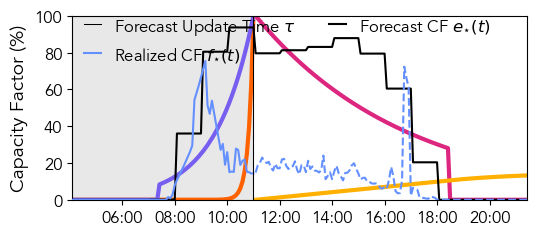

In [101]:
_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True
)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_, 
    _fdu.phi_, _fdu.psi_, _fdu.eta_, 
    f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval=interval,
    n=120,
    range_=[48, 256],
    labels_1=True,
    labels_2=False
)

_ax.legend(
    frameon=False, 
    ncol=2, 
    loc=(0.0125,0.7), 
    #loc=(0.362,0.625), 
    fontsize=12
)
        
plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

(131, 156)


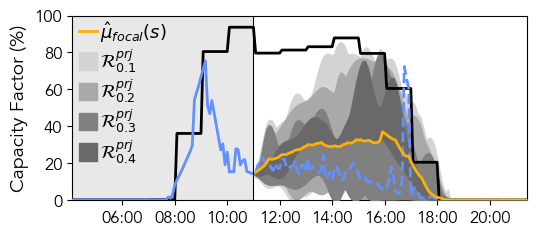

In [102]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

J_ = _fdu.focal_curve_envelope(
    None, 
    M_int_, 
    distance,
)
print(J_.shape)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score,
)

f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_region(
    alpha_, 
    k_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_envelope(
    _fig, 
    _ax, 
    palette_,
    _upper, 
    _lower, 
    f_focal_ext_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5,
    interval = interval,
    n=120,
    color_med=palette_.loc[4, "ibm"],
    label = r"$\hat{\mu}_{focal} (s)$",
    CR=r"$\mathcal{{R}}^{{prj}}_{{{}}}$",
    range_=[48, 256],
    legend_1=False,
    legend_2=True,
)

_ax.legend(
    frameon = False,
    loc = (0., .15),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


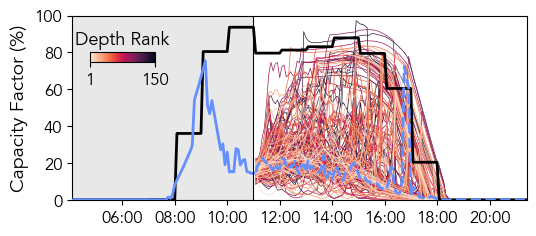

In [103]:
distance = 'MBD'
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval) /12),

)

depth_score_, depth_rank_ = _fdu.get_depth(_depth, M_int_)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_depth(
    _fig, 
    _ax, 
    palette_,
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    depth_rank_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n=120,
    range_=[48, 256],
    colorbar=True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .775),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_ranking-{file_name}.pdf")

plt.show()

In [104]:
# # Calculate confidence intervals from Directional Quantiles
# f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
#     M_int_, 
#     depth_score_
# )

# _fig, _ax = plt.subplots(
#     figsize = (5.25, 2.25), constrained_layout = True)

# plotter.plot_enhanced_functional_boxplot(
#     _fig, _ax, palette_,
#     _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
#     dt_ = dt_ + 5, 
#     interval = interval,
#     n=120,
#     range_=[48, 256],
#     legend_1=False,
#     legend_2=False,
# )

# _ax.legend(
#     frameon = False,
#     loc = (0.1875, .825),
#     fontsize = 12,
#     columnspacing=0.5,
#     handletextpad=0.2,
#     ncol = 6
# )

# plt.savefig(IMAGES / f"fboxplot-{distance}_{file_name}.pdf")

# plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


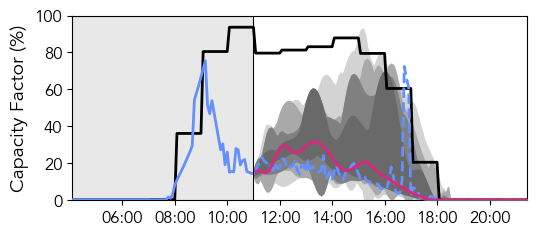

In [105]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()


M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    #n_basis=16
    n_basis=int(1.333*(T - interval)/12),

)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score,
)

f_deepest_ext_, _upper, _lower = _fdu.adjusted_functional_confidence_region(
    _depth, 
    M_int_, 
    alpha_, 
    k_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval=interval,
    n=120,
    color_med=palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR=r"$\mathcal{{R}}^{{adj}}_{{{}}}$",
    range_=[48, 256],
    legend_1=False,
    legend_2=False,
)


_ax.legend(
    frameon = False,
    loc = (0.0125, .15),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_adj_regions-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


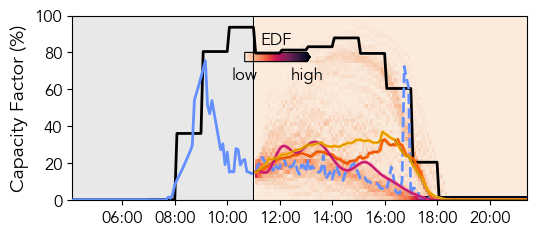

In [106]:
_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_density_heatmap(
    _fig, 
    _ax, 
    palette_,
    M_, 
    f_wmedian_ext_, 
    f_deepest_ext_, 
    f_focal_ext_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_=[48, 256],
    colorbar_pos = [640, 75, 150, 5],
    colorbar = True,
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .5),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

[-99.78  29.21]


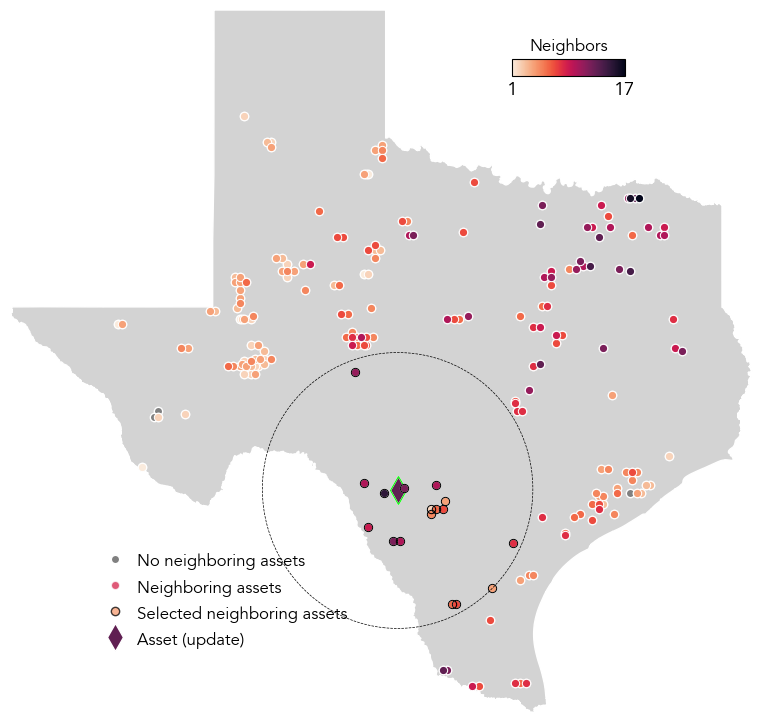

In [107]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 7.5), 
    constrained_layout=True
)
print(_fdu.x_)

plotter.plot_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)
_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.475, 0.25), 
    ncol=1, 
    fontsize=12
)

plt.savefig(IMAGES / f"spatial_neiboring_assets-{file_name}.pdf")

plt.show()

 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_85675/1015223596.py:18: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_85675/1015223596.py:18: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


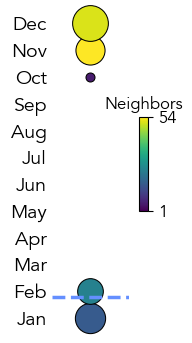

In [108]:
_fig, _ax = plt.subplots(
    figsize=(1, 4), 
    constrained_layout=True,
)

plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    T_tr_[:, interval], 
    _fdu.date,
    scale = 1.5,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neibors-{file_name}.pdf")

plt.show()

(1069,) (76593,) (1069,) (150,)


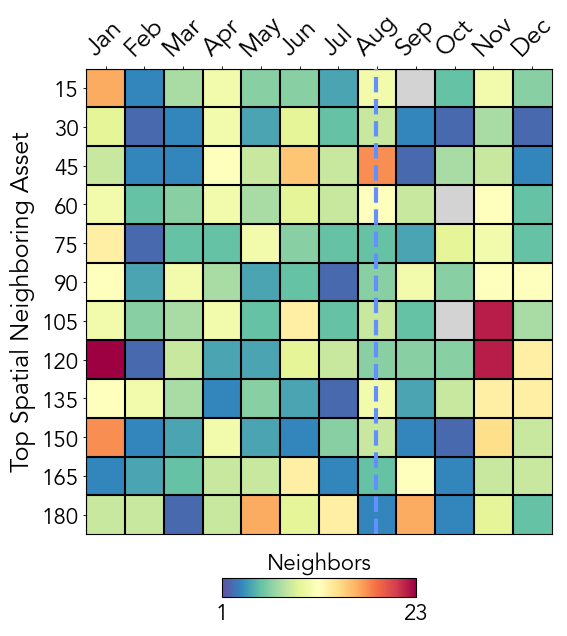

In [115]:
fig, _ax = plt.subplots(
    figsize=(7.5, 6.25), 
    constrained_layout=True,
)

plotter.selected_scenarios_heatmap(
    _fig, 
    _ax, 
    palette_,
    _fdu._haversine_dist, 
    _fdu.idx_fed_, 
    _fdu.idx_x_local_,
    _fdu.d_x_,
    _fdu.x_, 
    T_tr_[:, interval], 
    X_ts_,
    _fdu.date,
    colorbar = True,
)

plt.savefig(IMAGES / f"spatiotemporal_heatmap-{file_name}.pdf")

plt.show()

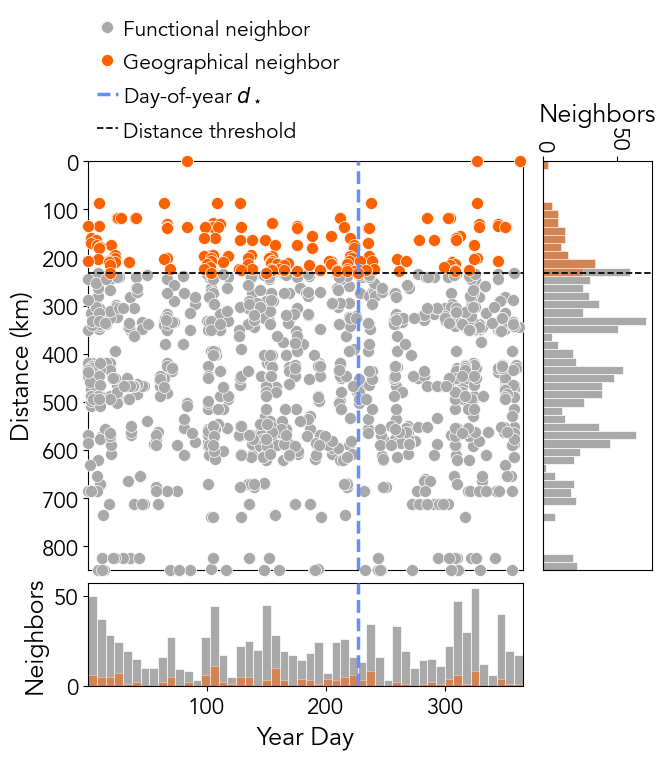

In [116]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, 
    _ax["A"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
    _fdu.r,
)

plotter.plot_distance_histogram(
    _fig, 
    _ax["B"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_, 
    _fdu.r,
)

plotter.plot_dates_histogram(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
)

_ax["A"].legend(
    frameon = False,
    ncol = 1,
    columnspacing = 0.625,
    handletextpad = 0.25,
    loc = (0.0, 1.025),
    fontsize = 15,
)

plt.savefig(IMAGES / f"spatiotemporal_neighbors-{file_name}.pdf")

plt.show()

TypeError: plot_density_threshold() missing 2 required positional arguments: 'label1' and 'label2'

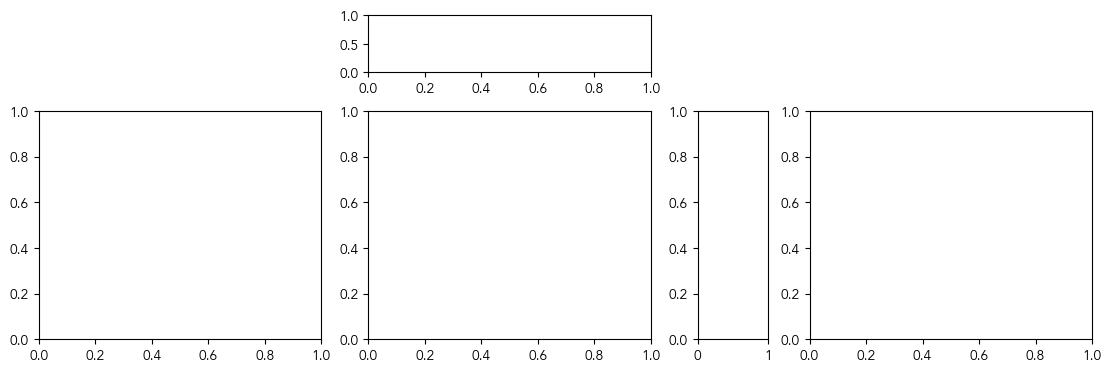

In [117]:
fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, _ax["A"], palette_, 
    _fdu.d_f_, _fdu.d_e_, _fdu.w_f_, _fdu.w_e_, _fdu.xi)

plotter.plot_functional_neighborhood(
    _fig, _ax["B"], _ax["e"], _ax["f"], palette_, 
    _fdu.idx_neighbors_, _fdu.w_f_, _fdu.w_e_, _fdu.xi
)

plotter.plot_selected_functional_neighbors(
    _fig, _ax["C"], palette_, _fdu.idx_neighbors_, _fdu.idx_temporal_,
    _fdu.idx_spatial_, _fdu.w_f_, _fdu.w_e_, _fdu.w_, _fdu.xi,
)

_ax["C"].legend(
    frameon=False, 
    fontsize=12, 
    ncol=1, 
    loc=(1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor-{file_name}.pdf")

plt.show()

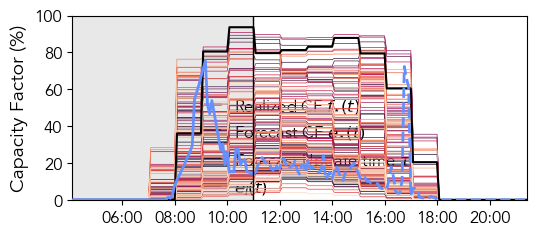

In [109]:
_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_forecasts(
    _fig, 
    _ax, 
    palette_, 
    E_tr_biased_,
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ + 5, 
    interval,
    range_=[48, 256],
    legend_1 = True,
    legend_2 = True,
)

_ax.legend(
    loc = (0.275, -0.025),
    frameon = False,
    fontsize = 12,
    ncol = 1,
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

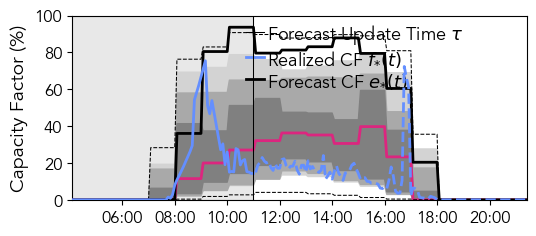

In [114]:
depth_score_, depth_rank_ = _fdu.get_depth(_depth, E_tr_biased_[_fdu.idx_x_, :])

# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    E_tr_biased_[_fdu.idx_x_, :], 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{{}}}$",
    n = 120,
    range_=[48, 256],
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.3675, .55),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 1,
)

plt.savefig(IMAGES / f"{distance}_box_forecast-{file_name}.pdf")

plt.show()

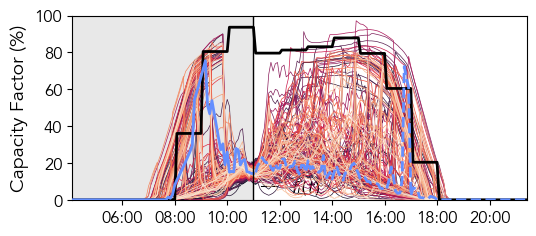

In [112]:
_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_neighbors(
    _fig, 
    _ax, 
    palette_, 
    F_tr_,     
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_,
    dt_ + 5, 
    interval,
    range_=[48, 256],
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    loc=(0.4, -0.025),
    frameon=False,
    fontsize=12,
    ncol=1,
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


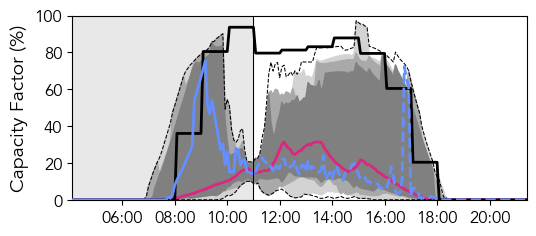

In [115]:
depth_score_, depth_rank_ = _fdu.get_depth(_depth, F_tr_[_fdu.idx_x_, :])

# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    F_tr_[_fdu.idx_x_, :], 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{{}}}$",
    n = 120,
    range_=[48, 256],
    legend_1 = False,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .625),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3,
)

plt.savefig(IMAGES / f"{distance}_box_realized-{file_name}.pdf")

plt.show()

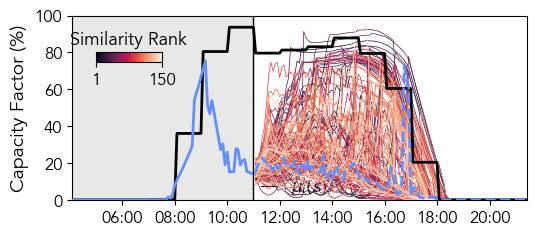

In [111]:
_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_updates(
    _fig, 
    _ax, 
    palette_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
     _fdu.w_fed_, 
    _fdu.idx_x_, 
    dx_, 
    dt_ + 5, 
    interval,
    range_=[48, 256],
    legend_1=True,
    legend_2=False,
    colorbar_pos = [300, 75, 150, 5],
)

_ax.legend(
    loc=(0.4, -0.025),
    frameon = False,
    fontsize = 12,
    ncol = 1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

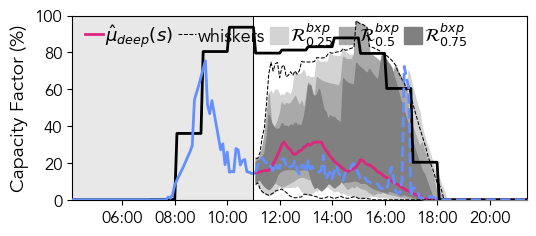

In [116]:
depth_score_, depth_rank_ = _fdu.get_depth(_depth, M_)

# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    M_, 
    depth_score_,
)

_fig, _ax = plt.subplots(
    figsize = (5.25, 2.25), 
    constrained_layout = True,
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{{}}}$",
    n = 120,
    range_=[48, 256],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .775),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 5,
)

plt.savefig(IMAGES / f"{distance}_box_fused-{file_name}.pdf")

plt.show()

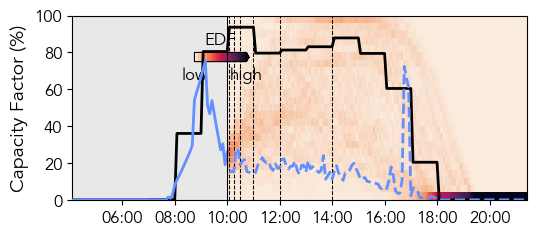

In [53]:
slices_ = [3, 6, 12, 24, 48]

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_heatmap_slices(
    _fig, _ax, palette_, _fdu.M_, f_, f_hat_, 
    e_biased_, dx_, dt_ + 5, interval,
    slices_ = slices_,
    range_=[48, 256],
    colorbar = True,
)

# _ax.legend(
#     #loc = (0.0625, 1), 
#     frameon = False, 
#     fontsize = 12, 
#     ncol = 4
# )

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

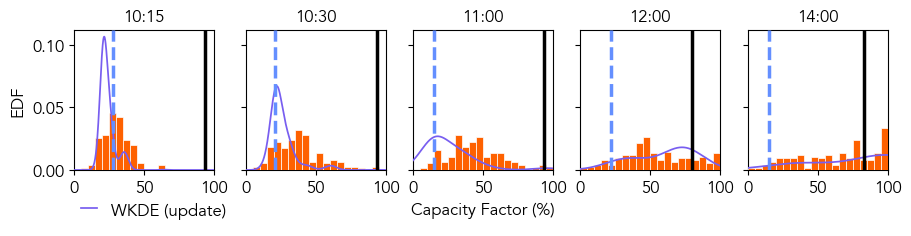

In [54]:
KDs_ = _fdu.weighted_kernel_density_estimation(
    100*M_, 
    weights = _fdu.w_fed_[_fdu.idx_x_local_],
    algorithm = "auto", 
    kernel = "gaussian"
)

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize=(9, 2.25), 
    sharey=True, 
    layout="constrained"
)

plotter.plot_histogram_cuts(
    _fig, _ax, palette_, 
    KDs_, M_, f_, f_hat_, e_biased_, dx_, dt_, interval, 
    slices_ = slices_)

_ax[0].legend(
    frameon = False, 
    fontsize = 12, 
    loc = (0, -0.4)
)

plt.savefig(IMAGES / f"marginal_density_cutoffs-{file_name}.pdf")

plt.show()

In [96]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(84, 216, 3):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset], E_ts_lin_[day, :, asset], X_ts_[asset, :], t_ts_[day],          
        forget_rate_f=get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e=get_hyper(hyper_, "forget_rate_e", interval),
        lookahead_rate = get_hyper(hyper_, 'lookahead_rate', interval),
        length_scale_f=get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e=get_hyper(hyper_, "length_scale_e", interval),
        length_scale_d=get_hyper(hyper_, "length_scale_d", interval),
        nu=get_hyper(hyper_, "nu", interval),
        sigma=get_hyper(hyper_, "sigma", interval),
        kappa_0=get_hyper(hyper_, "kappa_0", interval),
        kappa=get_hyper(hyper_, "kappa", interval),
        p_fusion=get_hyper(hyper_, "p_fusion", interval),
    )


    # Samples in each confidence band
    score = 'FCS'
    distance = 'MBD'
    alpha_ = [0.1, 0.2, 0.3, 0.4]
    _depth = ModifiedBandDepth()
    
    
    M_int_, M_int_ds_ = _fdu.functional_downsampling(
        subsample=12, 
        n_basis=20
    )

    f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_region(
        M_int_, 
        _fdu.w_prime_,
        alpha_
    )
    
    k_ = get_band_fraction(
        envelope_, 
        alpha_, 
        interval, 
        distance, 
        score
    )
    
    f_deepest_ext_, _upper, _lower = _fdu.adjusted_functional_confidence_region(
        _depth, 
        M_int_, 
        alpha_, 
        k_
    )

    M_curves_.append(f_wmedian_ext_[1:])
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(f_deepest_ext_[1:])

print(len(F_curves_), len(M_curves_), len(D_curves_))

44 44 44


In [ ]:
_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5,
    label="Focal curves",
    range_=[48, 256],
    legend=True,
    colorbar=True,
)

# _ax.legend(
#     loc=(0.2, 0.0125), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    M_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_=[48, 256],
    legend=True,
    colorbar=False,
    label="Marginal medians"
)

# _ax.legend(
#     loc=(0.25, 0.0), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-median_marginals-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize = (5.25, 2.25), constrained_layout = True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    D_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_=[48, 256],
    legend=True,
    colorbar=False,
    label="Deepest curves"
)

# _ax.legend(
#     loc=(0.25, 0.0), 
#     frameon=False, 
#     fontsize=12, 
#     ncol=3
# )

plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

plt.show()

In [ ]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0=0.005, 
    y0=0.7, 
    width=0.25, 
    height=0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
    marker='^',
)


# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy=(x, y),
    xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor="k", 
                    arrowstyle="wedge,tail_width=1,shrink_factor=.5"),
    ha="center",
    va="center",
    fontsize=14,
    xycoords=_ax.transAxes,
)

scalebar = ScaleBar(
    dx=100,  # scaling factor
    units="km",
    dimension="si-length",  # could also be 'imperial-length.'
    location="lower left",
    length_fraction=0.09,  # fraction of the axis for bar length
    color="black",
    box_color="None",
    box_alpha=1.0,
    border_pad=9,
    font_properties={"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon=False, 
    bbox_to_anchor=(0.625, 0.9875), 
    ncol=1, 
    fontsize=14
)

plt.savefig(IMAGES / f"hillshade_neighboring_assets-{file_name}.pdf")

plt.show()

In [ ]:
# # solar asset
# resource = 'solar'
# type = 'asset'
# description = 1
# method = 'fusion'
# score = 'FCS'

# hyper_, envelope_, validation_ = _load_hyperparamerters(resource, method, type, score, description, 
#                                                         path = path_to_validation)

# # interval = 120
# # lead = 12
# # horizon = [0, 12, 24, 36, 48, 60][2]
# interval = 144 
# lead = 9
# horizon = [0, 9, 18, 27, 36, 45][2]
# # interval = 168 
# # lead = 6
# # horizon = [0, 6, 12, 18, 24, 30][2]

# pit_ = _load_pit(validation_, resource, method, type, interval, description, 
#                  path = path_to_validation)

# print(pit_.shape)

# _fig, _ax = plt.subplots(1, 1, 
#                         figsize = (2.3, 2.25), 
#                         layout  = "constrained")

# _plot_PIT(_ax, pit_[:, horizon:(horizon + lead)].flatten(), 
#           bins = 10,
#           xlabel = 'PIT (1h to 48h lead)')

# # plt.savefig(path_to_images + f"/PIT-{resource}-{method}-{type}-{interval}-{horizon}.pdf", 
# #             bbox_inches="tight")


# plt.show()